# 2 The Solow model with a time-varying savings rate

In [22]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from SolowModel import SolowModelClass

### 2.1 Question 1

#### 2.1.1 Steady state
Using `SolowModelClass` and $s=\bar{s}=0.25$, the analytical steady-state values are:

- $k^*=0.760726$
- $y^*=0.912871$
- $c^*=0.684653$

The root finder gives $k^*=0.760726$, which confirms the analytical solution.

#### 2.1.2 Baseline simulation

The model is simulated for $T=100$ periods with $s_t=\bar{s}=0.25$ and $k_0=0.10$:

- $c_0=0.348119$
- $c_{T-1}=0.684653$
- $k_{T-1}=0.760726$

Capital, output and consumption converge toward their steady-state values.

#### 2.1.3 Simulator tests

Both tests pass:

- An economy starting at $k^*$ remains at $k^*$.
- With $s_t=0$, capital follows $k_t=(1-\delta)^t k_0$.

The simulator is implemented in `SolowModel.py`, while this notebook contains the analysis and figures.


k* = 0.760726
y* = 0.912871
c* = 0.684653
k* (root finder) = 0.760726


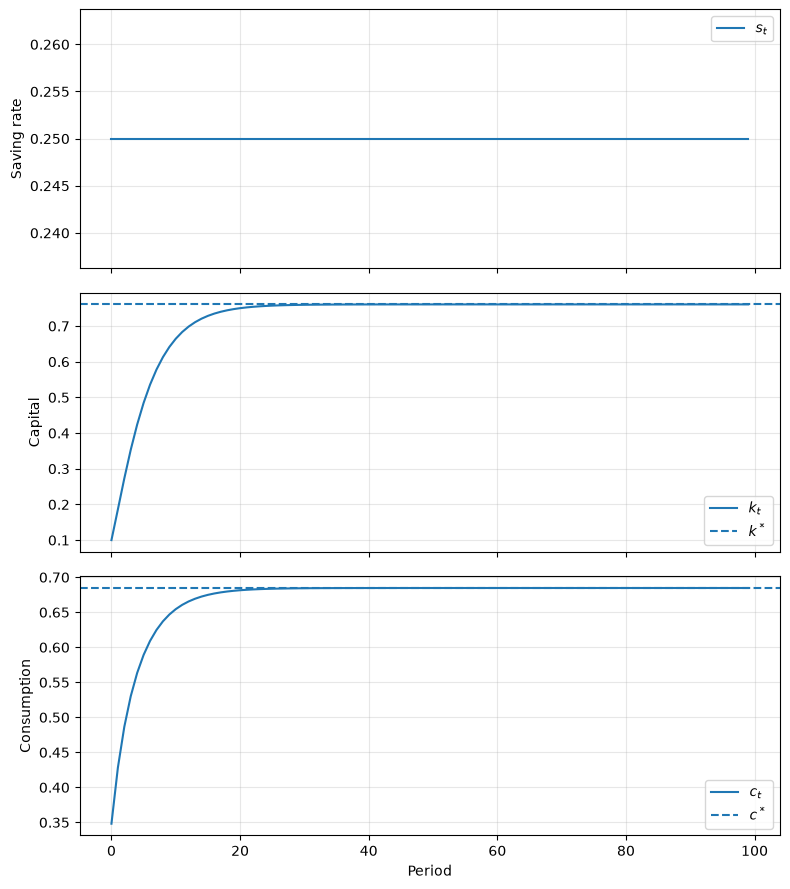

c0 = 0.348119
c(T-1) = 0.684653
k(T-1) = 0.760726
all tests passed


In [23]:
# 2.1 Model setup and analytical steady state
model = SolowModelClass()
par = model.par
k_star, y_star, c_star = model.steady_state()
k_root = model.solve_steady_state()

print(f'k* = {k_star:.6f}')
print(f'y* = {y_star:.6f}')
print(f'c* = {c_star:.6f}')
print(f'k* (root finder) = {k_root:.6f}')
assert np.isclose(k_star, k_root)

# 2.1.2 Baseline simulation
baseline = model.simulate(par.s_bar)

fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
ax[0].plot(baseline.s, label=r'$s_t$')
ax[0].set_ylabel('Saving rate')
ax[0].legend()
ax[0].grid(alpha=0.3)
ax[1].plot(baseline.k, label=r'$k_t$')
ax[1].axhline(k_star, linestyle='--', label=r'$k^*$')
ax[1].set_ylabel('Capital')
ax[1].legend()
ax[1].grid(alpha=0.3)
ax[2].plot(baseline.c, label=r'$c_t$')
ax[2].axhline(c_star, linestyle='--', label=r'$c^*$')
ax[2].set_ylabel('Consumption')
ax[2].set_xlabel('Period')
ax[2].legend()
ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'c0 = {baseline.c[0]:.6f}')
print(f'c(T-1) = {baseline.c[-1]:.6f}')
print(f'k(T-1) = {baseline.k[-1]:.6f}')

# 2.1.3 Tests with known answers
def test_simulator():
    steady = SolowModelClass()
    steady_sim = steady.simulate(steady.par.s_bar, k0=k_star)
    assert np.allclose(steady_sim.k, k_star)

    decay = SolowModelClass()
    decay_sim = decay.simulate(0.0)
    expected = decay.par.k0 * (1 - decay.par.delta) ** np.arange(decay.par.T)
    assert np.allclose(decay_sim.k, expected)
    print('all tests passed')

test_simulator()

### 2.2 Question 2

#### 2.2.1-2 Time-varying savings rule and simulations

The model class implements

$$s_t=\bar{s}+(s_0-\bar{s})\phi^t.$$

A higher $s_0$ changes saving mainly in the first periods. Higher initial saving lowers consumption initially, but raises capital and therefore later output and consumption. The parameter $\phi$ controls how persistent the initial deviation is: a higher $\phi$ makes the saving rate return more slowly toward $\bar{s}$.

#### 2.2.3 Final capital

| Case | $k_{T-1}$ |
|---|---:|
| Baseline | 0.760726 |
| $s_0=0.30,\ \phi=0.50$ | 0.760726 |
| $s_0=0.40,\ \phi=0.80$ | 0.760726 |
| $s_0=0.10,\ \phi=0.50$ | 0.760726 |
| $s_0=0.60,\ \phi=0.60$ | 0.760726 |

The values are equal to six decimal places because all rules converge toward the same long-run saving rate $\bar{s}$. They are not exactly equal at period $T-1$, since the temporary saving paths affect capital accumulation for many periods.

#### 2.2.4 Interpretation

The figure shows the short-run trade-off clearly. The rule with $s_0=0.60$ has the lowest initial consumption and the highest early capital accumulation. The rule with $s_0=0.10$ has higher initial consumption but lower capital at first. A higher $\phi$ prolongs these effects. As the saving rates converge to $\bar{s}$, all paths converge toward the same steady state.


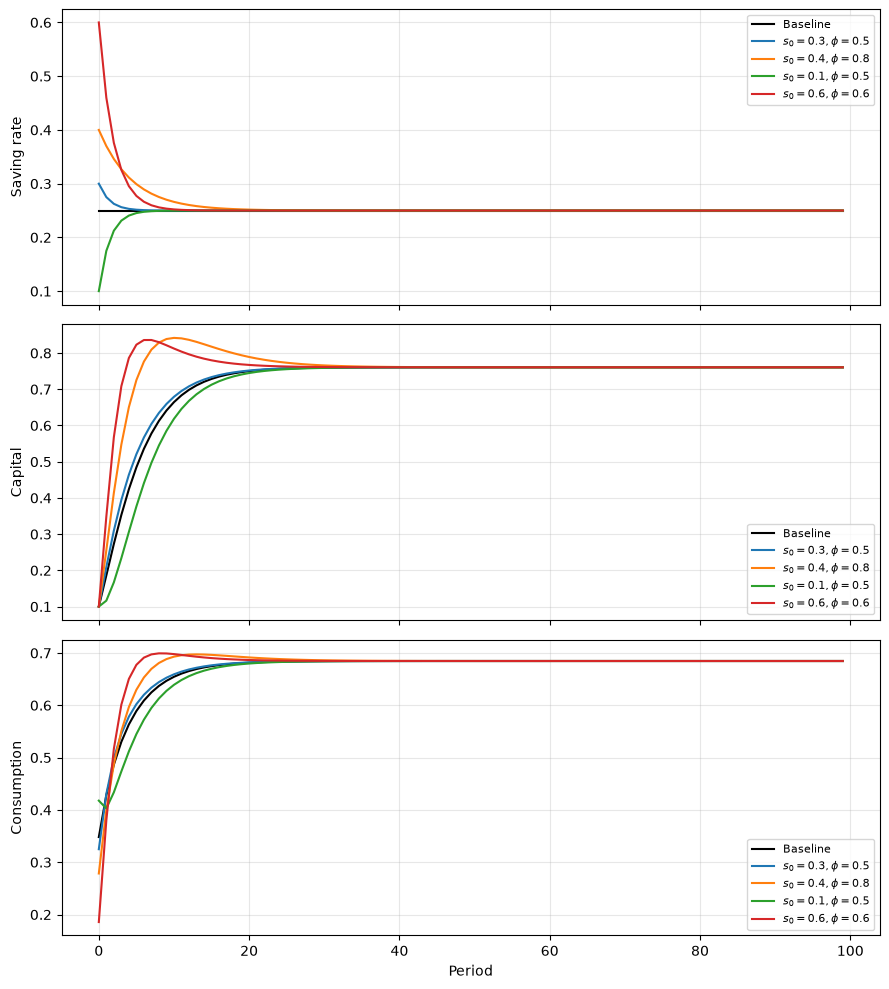

Baseline: k(T-1) = 0.760726
s0=0.3, phi=0.5: k(T-1) = 0.760726
s0=0.4, phi=0.8: k(T-1) = 0.760726
s0=0.1, phi=0.5: k(T-1) = 0.760726
s0=0.6, phi=0.6: k(T-1) = 0.760726


In [24]:
# 2.2 Time-varying savings rule and simulations
cases = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]
models = {}

for s0, phi in cases:
    case_model = SolowModelClass()
    case_model.simulate(case_model.s_path(s0, phi))
    models[(s0, phi)] = case_model

fig, ax = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
series = [(None, 'Baseline', 'black')]
for (s0, phi), case_model in models.items():
    series.append(((s0, phi), f'$s_0={s0},\\phi={phi}$', None))

for key, label, color in series:
    sim = baseline if key is None else models[key].sim
    line_color = color if color else None
    ax[0].plot(sim.s, label=label, color=line_color)
    ax[1].plot(sim.k, label=label, color=line_color)
    ax[2].plot(sim.c, label=label, color=line_color)

ax[0].set_ylabel('Saving rate')
ax[1].set_ylabel('Capital')
ax[2].set_ylabel('Consumption')
ax[2].set_xlabel('Period')
for axis in ax:
    axis.legend(fontsize=8)
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Baseline: k(T-1) = {baseline.k[-1]:.6f}')
for (s0, phi), case_model in models.items():
    print(f's0={s0}, phi={phi}: k(T-1) = {case_model.sim.k[-1]:.6f}')

### 2.3 Question 3

#### 2.3.1-2 Welfare results

| Case | $W$ | $W-W_{\mathrm{baseline}}$ |
|---|---:|---:|
| Baseline | -3.994388 | 0.000000 |
| $s_0=0.30,\ \phi=0.50$ | -3.985706 | 0.008682 |
| $s_0=0.40,\ \phi=0.80$ | -4.091413 | -0.097025 |
| $s_0=0.10,\ \phi=0.50$ | -4.146018 | -0.151630 |
| $s_0=0.60,\ \phi=0.60$ | -4.340653 | -0.346265 |

#### 2.3.3 Comparison

Only $(s_0,\phi)=(0.30,0.50)$ gives higher welfare than the baseline. This rule increases saving moderately in the first period and returns quickly toward $\bar{s}$. The figure alone does not identify the best rule, because welfare is a discounted sum of consumption over the whole path.


In [25]:
# 2.3 Welfare for the baseline and the four time-varying rules
W_baseline = model.welfare(baseline.c)
rows = [{'Case': 'Baseline', 'W': W_baseline, 'Delta W': 0.0}]

for (s0, phi), case_model in models.items():
    W = case_model.welfare(case_model.sim.c)
    rows.append({'Case': f's0={s0}, phi={phi}', 'W': W, 'Delta W': W - W_baseline})

welfare_df = pd.DataFrame(rows)
print(welfare_df.round(6).to_string(index=False))
print('\nRules with welfare above baseline:')
print(welfare_df[(welfare_df['Delta W'] > 0) & (welfare_df['Case'] != 'Baseline')].to_string(index=False))

           Case         W   Delta W
       Baseline -3.994388  0.000000
s0=0.3, phi=0.5 -3.985706  0.008682
s0=0.4, phi=0.8 -4.091413 -0.097025
s0=0.1, phi=0.5 -4.146018 -0.151630
s0=0.6, phi=0.6 -4.340653 -0.346265

Rules with welfare above baseline:
           Case         W  Delta W
s0=0.3, phi=0.5 -3.985706 0.008682


### 2.4 Question 4

#### 2.4.1 Grid search

The welfare grid uses $s_0\in[0,0.60]$ and $\phi\in[0,0.95]$. The best grid point is:

- $s_0=0.310$
- $\phi=0.230$
- $W=-3.984306$

#### 2.4.2 Numerical optimization

Starting from the best grid point, the optimizer finds:

- $s_0=0.311319$
- $\phi=0.229976$
- $W=-3.984301$

The optimizer improves welfare by only $0.000005$ relative to the grid point, so the grid already locates the optimum very closely.

#### 2.4.3 Best rule compared with the baseline

For the optimized rule, $c_0=0.319658$, and consumption is above the baseline for the first time in period 1. The optimized rule saves more than the baseline initially, which lowers current consumption but raises capital and consumption shortly afterward.


Best grid point: s0=0.310, phi=0.230, W=-3.984306


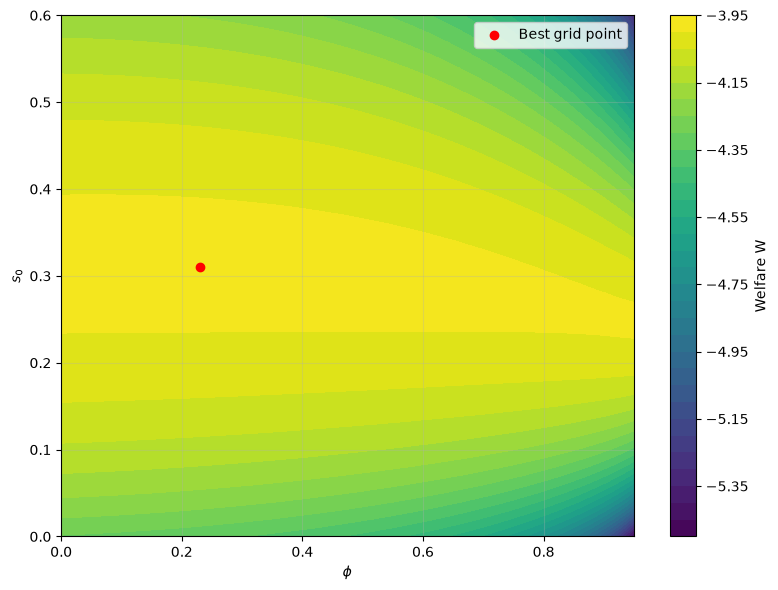

Optimized solution: s0=0.311319, phi=0.229976, W=-3.984301
Difference from grid welfare: 0.000005


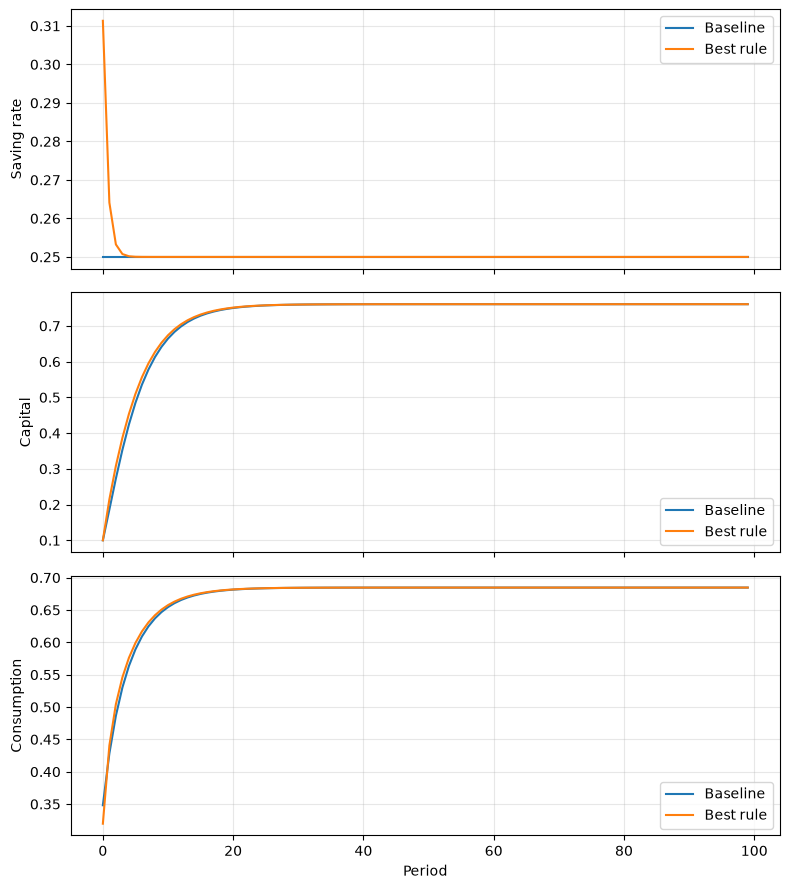

c0 = 0.319658
First period with c above baseline: 1


In [26]:
# 2.4 Grid search over s0 and phi
s0_grid = np.linspace(0, 0.60, 61)
phi_grid = np.linspace(0, 0.95, 96)
W_grid = np.empty((len(s0_grid), len(phi_grid)))

grid_model = SolowModelClass()
for i, s0 in enumerate(s0_grid):
    for j, phi in enumerate(phi_grid):
        W_grid[i, j] = grid_model.evaluate(s0, phi)

best_idx = np.unravel_index(np.argmax(W_grid), W_grid.shape)
best_s0 = s0_grid[best_idx[0]]
best_phi = phi_grid[best_idx[1]]
best_W = W_grid[best_idx]
print(f'Best grid point: s0={best_s0:.3f}, phi={best_phi:.3f}, W={best_W:.6f}')

plt.figure(figsize=(8, 6))
plt.contourf(phi_grid, s0_grid, W_grid, levels=30)
plt.colorbar(label='Welfare W')
plt.scatter(best_phi, best_s0, color='red', label='Best grid point')
plt.xlabel(r'$\phi$')
plt.ylabel(r'$s_0$')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2.4.2 Numerical optimization from the best grid point
def objective(x):
    return -grid_model.evaluate(x[0], x[1])

opt = minimize(objective, x0=[best_s0, best_phi], method='SLSQP',
               bounds=[(0, 0.60), (0, 0.95)])
assert opt.success, opt.message
opt_s0, opt_phi = opt.x
opt_W = -opt.fun
print(f'Optimized solution: s0={opt_s0:.6f}, phi={opt_phi:.6f}, W={opt_W:.6f}')
print(f'Difference from grid welfare: {opt_W - best_W:.6f}')

# 2.4.3 Plot the optimized rule against the baseline
opt_model = SolowModelClass()
opt_sim = opt_model.simulate(opt_model.s_path(opt_s0, opt_phi))
fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
for axis, baseline_values, optimized_values, ylabel in [
    (ax[0], baseline.s, opt_sim.s, 'Saving rate'),
    (ax[1], baseline.k, opt_sim.k, 'Capital'),
    (ax[2], baseline.c, opt_sim.c, 'Consumption')]:
    axis.plot(baseline_values, label='Baseline')
    axis.plot(optimized_values, label='Best rule')
    axis.set_ylabel(ylabel)
    axis.legend()
    axis.grid(alpha=0.3)
ax[2].set_xlabel('Period')
plt.tight_layout()
plt.show()

above = np.where(opt_sim.c > baseline.c)[0]
first_above = above[0] if above.size else None
print(f'c0 = {opt_sim.c[0]:.6f}')
print(f'First period with c above baseline: {first_above}')

### 2.5 Question 5

#### 2.5.1 Three-parameter optimization

When the long-run saving rate is also chosen, the rule is

$$s_t=s_\infty+(s_0-s_\infty)\phi^t.$$

The optimizer finds:

- $s_0=0.313903$
- $\phi=0.670364$
- $s_\infty=0.198959$
- $W=-3.966965$

Welfare improves by $0.017336$ compared with the optimized two-parameter rule in Question 2.4.

#### 2.5.2 Final capital

The simulated value is $k_{T-1}=0.540088$, compared with the original steady state $k^*=0.760726$. The two values should not be the same: the long-run saving rate is now $s_\infty$, so the relevant steady state is

$$k_\infty^*=\left(\frac{s_\infty}{\delta}\right)^{1/(1-\alpha)}=0.540088.$$

Thus, the economy has converged to the steady state associated with the new long-run saving rate.


In [27]:
# 2.5 Optimize the three-parameter savings rule

def savings_rule_three(s0, phi, s_inf, T):
    t = np.arange(T)
    return s_inf + (s0 - s_inf) * phi**t

three_model = SolowModelClass()
def objective_three(x):
    s0, phi, s_inf = x
    return -three_model.welfare(
        three_model.simulate(savings_rule_three(s0, phi, s_inf, three_model.par.T)).c
    )

opt3 = minimize(objective_three, x0=[opt_s0, opt_phi, par.s_bar], method='SLSQP',
                bounds=[(0, 1), (0, 0.999), (0, 1)])
assert opt3.success, opt3.message
s0_best, phi_best, s_inf_best = opt3.x
W_best3 = -opt3.fun
sim3 = three_model.simulate(savings_rule_three(s0_best, phi_best, s_inf_best, par.T))

print(f's0 = {s0_best:.6f}')
print(f'phi = {phi_best:.6f}')
print(f's_inf = {s_inf_best:.6f}')
print(f'W = {W_best3:.6f}')
print(f'Improvement over Q2.4 = {W_best3 - opt_W:.6f}')
print(f'k(T-1) = {sim3.k[-1]:.6f}')
print(f'Original k* = {k_star:.6f}')
k_inf = (s_inf_best / par.delta)**(1 / (1 - par.alpha))
print(f'New long-run k* = {k_inf:.6f}')

s0 = 0.313903
phi = 0.670364
s_inf = 0.198959
W = -3.966965
Improvement over Q2.4 = 0.017336
k(T-1) = 0.540088
Original k* = 0.760726
New long-run k* = 0.540088


### 2.6 Question 6

#### 2.6.1-2 Alternative savings rule

As an alternative to the exponential rule, I use a hyperbolic rule:

$$s_t=s_\infty+\frac{s_0-s_\infty}{1+\rho t}.$$

The rule converges to the constant long-run level $s_\infty$, so the economy still converges toward a steady state. Numerical optimization gives:

- $s_0=0.315583$
- $\rho=0.494439$
- $s_\infty=0.179510$
- $W=-3.967244$

#### 2.6.3 Welfare comparison

| Rule | $W$ |
|---|---:|
| Baseline | -3.994388 |
| Best Q2.4 | -3.984301 |
| Best Q2.5 | -3.966965 |
| Alternative | -3.967244 |

The alternative rule improves on the baseline and the two-parameter rule, but it does not beat the optimized three-parameter exponential rule from Question 2.5.


In [28]:
# 2.6 Alternative savings rule

def savings_rule_alternative(s0, rho, s_inf, T):
    t = np.arange(T)
    return s_inf + (s0 - s_inf) / (1 + rho * t)

alternative_model = SolowModelClass()
def objective_alternative(x):
    s0, rho, s_inf = x
    s = savings_rule_alternative(s0, rho, s_inf, alternative_model.par.T)
    return -alternative_model.welfare(alternative_model.simulate(s).c)

opt_alternative = minimize(objective_alternative,
                           x0=[s0_best, 1.0, s_inf_best],
                           method='SLSQP',
                           bounds=[(0, 0.60), (0, 10.0), (0, 0.60)])
assert opt_alternative.success, opt_alternative.message
s0_alternative, rho_alternative, s_inf_alternative = opt_alternative.x
W_alternative = -opt_alternative.fun

print(f's0 = {s0_alternative:.6f}')
print(f'rho = {rho_alternative:.6f}')
print(f's_inf = {s_inf_alternative:.6f}')
print(f'W = {W_alternative:.6f}')

welfare_comparison = pd.DataFrame({
    'Rule': ['Baseline', 'Best Q2.4', 'Best Q2.5', 'Alternative'],
    'W': [W_baseline, opt_W, W_best3, W_alternative]
})
print(welfare_comparison.round(6).to_string(index=False))

s0 = 0.315583
rho = 0.494439
s_inf = 0.179510
W = -3.967244
       Rule         W
   Baseline -3.994388
  Best Q2.4 -3.984301
  Best Q2.5 -3.966965
Alternative -3.967244
